# Projeto de Machine Learning – FarmTech Solutions

## Autor
Caroline de Castro Corrêa
castrocaroline11@gmail.com

Enzo França Sader
efr4nca03@gmail.com

Lucas Hideki Oliveira Koyama
Lucaskoyamahhh@gmail.com

Rodrigo Dias Figueiroa
rdfigueiroa@gmail.com

Tiago Lindgren Curi
shopper.tiago@gmail.com

## Descrição do Projeto

Este projeto tem como objetivo analisar dados de condições climáticas e prever o rendimento de safras agrícolas utilizando técnicas de Machine Learning.

Serão aplicadas técnicas de análise exploratória de dados, clusterização (aprendizado não supervisionado) para identificação de padrões e possíveis outliers, e modelos de regressão supervisionada para prever o rendimento das culturas com base nas variáveis climáticas.

## Importação das bibliotecas necessárias

In [1]:
# Importação das bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Carregamento e visualização inicial do dataset

In [27]:
# Visualizando as primeiras linhas
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Cluster
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560,2
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,2
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456,2
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,2
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800,2


## Carregando o dataset

In [30]:
df = pd.read_csv("crop_yield.csv")

In [31]:
# Verificando o tamanho do dataset
df.shape

(156, 6)

In [32]:
# Informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [34]:
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


### Análise das estatísticas descritivas

As variáveis climáticas apresentam valores bastante estáveis, com médias próximas e desvios padrão baixos.  
- **Precipitação** varia entre ~1935 e ~3086 mm/dia, sem grandes discrepâncias.  
- **Umidade específica** e **umidade relativa** mostram pouca dispersão, indicando condições atmosféricas homogêneas.  
- **Temperatura** também é bastante uniforme, oscilando levemente entre 25,5 °C e 26,8 °C.  

Em contraste, o **Yield (produção agrícola)** apresenta grande variabilidade:  
- A média é ~56 mil, mas a mediana é ~188 mil.  
- O valor máximo ultrapassa 2 milhões, evidenciando a presença de **outliers**.  
- O desvio padrão elevado confirma a alta dispersão dos dados.  

**Conclusão:**  
Enquanto as variáveis climáticas são relativamente constantes, o rendimento agrícola é altamente heterogêneo, sugerindo que fatores adicionais ou interações complexas influenciam a produção. Essa característica reforça a importância da análise de outliers e da modelagem preditiva para compreender melhor os determinantes do Yield.

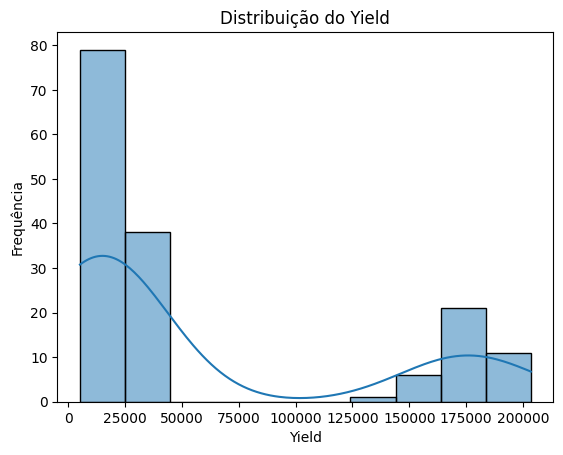

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['Yield'], kde=True)
plt.title("Distribuição do Yield")
plt.xlabel("Yield")
plt.ylabel("Frequência")
plt.show()

### Distribuição do Yield

O histograma com curva KDE mostra que a variável **Yield** apresenta uma distribuição bastante assimétrica.  
- A maior concentração de valores ocorre em faixas mais baixas de produção, com frequência elevada até aproximadamente 200 mil.  
- A curva KDE evidencia uma cauda longa à direita, indicando a presença de **outliers** com valores muito superiores à média.  
- Essa dispersão reforça o que já foi observado nas estatísticas descritivas: o rendimento agrícola varia de forma significativa, com alguns casos extremos que podem influenciar a análise.  

**Conclusão:**  
A distribuição do Yield não é normal e possui forte assimetria positiva. Essa característica deve ser considerada na modelagem, pois os outliers podem impactar tanto a regressão quanto a interpretação dos resultados.

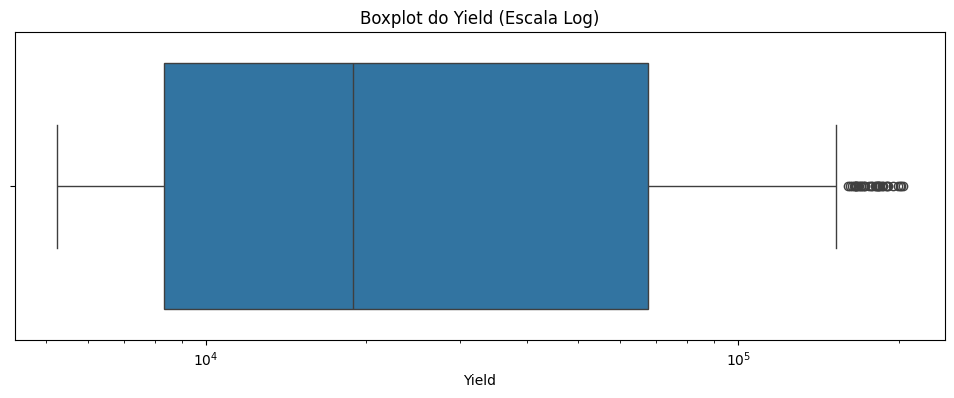

In [13]:
plt.figure(figsize=(12,4))
sns.boxplot(x=df['Yield'])
plt.xscale('log')
plt.title("Boxplot do Yield (Escala Log)")
plt.show()

### Boxplot do Yield (Escala Log)

O boxplot em escala logarítmica evidencia a grande dispersão dos valores de **Yield**.  
- A mediana está em torno de 188 mil, mas há valores muito superiores que se destacam como **outliers**.  
- A escala log foi necessária para permitir uma visualização mais clara, já que os valores variam de milhares até mais de 2 milhões.  
- Mesmo com a transformação, nota-se uma assimetria acentuada e a presença de pontos extremos que podem influenciar a análise estatística e os modelos preditivos.  

**Conclusão:**  
O Yield apresenta forte heterogeneidade e valores extremos. A identificação e o tratamento desses outliers serão etapas importantes para garantir maior robustez na modelagem preditiva.

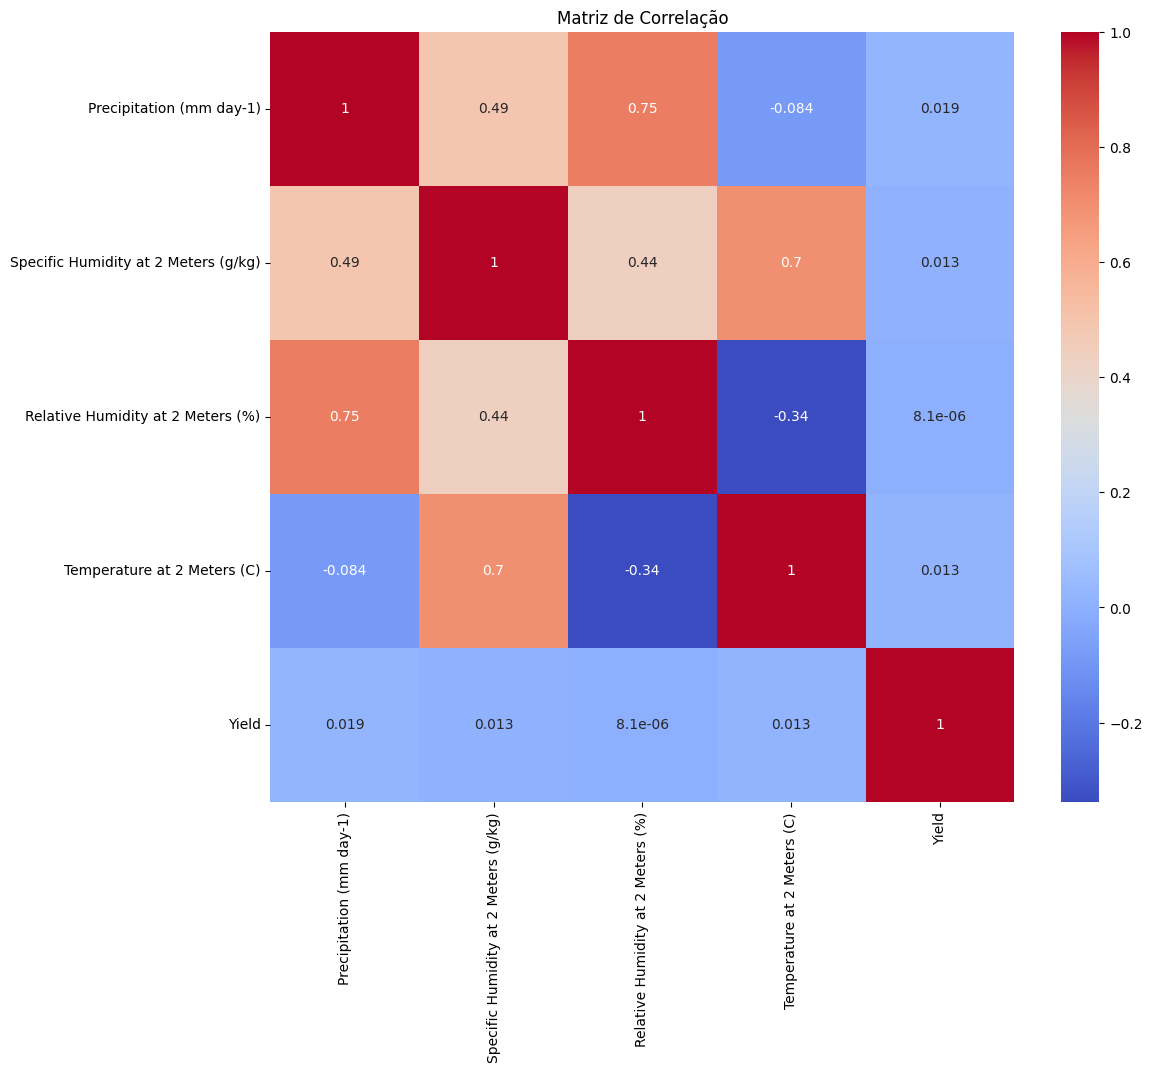

In [41]:
plt.figure(figsize=(12,10))  # aumenta largura e altura
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

### Matriz de Correlação Completa

A matriz de correlação mostra as relações entre variáveis climáticas, de solo e o rendimento agrícola (**Yield**):

- **Temperatura a 2m** apresenta:
  - Correlação negativa fraca com **Precipitação (-0.084)** e **Umidade do solo (%) (-0.34)**.  
  - Correlação positiva moderada com **Umidade do solo (g/kg) (0.70)**.  
  → Indica que a temperatura influencia de forma diferenciada os indicadores de umidade.

- **Yield** mostra correlações muito baixas com todas as variáveis:
  - Precipitação: 0.019  
  - Umidade do solo (g/kg): 0.013  
  - Umidade do solo (%): ~0  
  - Temperatura: 0.013  
  → Não há relação linear direta entre o rendimento e nenhuma variável isolada.

**Conclusão:**  
As variáveis climáticas e de solo apresentam correlações entre si, mas o **Yield** não se correlaciona fortemente com nenhuma delas de forma linear. Isso reforça a necessidade de aplicar **modelos de regressão supervisionada** ou técnicas mais complexas para capturar interações não lineares e compreender melhor os fatores que determinam o rendimento agrícola.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Definindo variáveis independentes (clima)
X = df[['Precipitation (mm day-1)',
        'Specific Humidity at 2 Meters (g/kg)',
        'Relative Humidity at 2 Meters (%)',
        'Temperature at 2 Meters (C)']]

# Variável dependente (o que queremos prever)
y = df['Yield']

# Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando modelo
model = LinearRegression()

# Treinando modelo
model.fit(X_train, y_train)

# Fazendo previsão
y_pred = model.predict(X_test)

# Avaliando modelo
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: -0.07303066291166482
MSE: 4162255539.8433895


### Avaliação do Modelo de Regressão Linear

O modelo de regressão linear múltipla foi treinado utilizando as variáveis climáticas como preditores do **Yield**.  
Os resultados obtidos foram:

- **R²:** -0.073  
- **MSE:** 4.162.255.539  

**Interpretação:**
- O valor negativo de **R²** indica que o modelo não conseguiu explicar a variabilidade do Yield. Na prática, isso significa que o modelo performou pior do que uma simples média dos valores.  
- O **MSE** elevado reforça que as previsões estão muito distantes dos valores reais, evidenciando baixa capacidade preditiva.  
- Esses resultados sugerem que a relação entre as variáveis climáticas e o Yield não é linear simples. É provável que existam **interações não lineares** ou outros fatores não incluídos no dataset que influenciem fortemente a produção agrícola.  

**Conclusão:**  
A regressão linear não é adequada para prever o Yield neste conjunto de dados. Será necessário testar modelos mais robustos, como **árvores de decisão**, **random forest** ou **modelos não lineares**, para capturar melhor a complexidade da relação entre clima e rendimento agrícola.

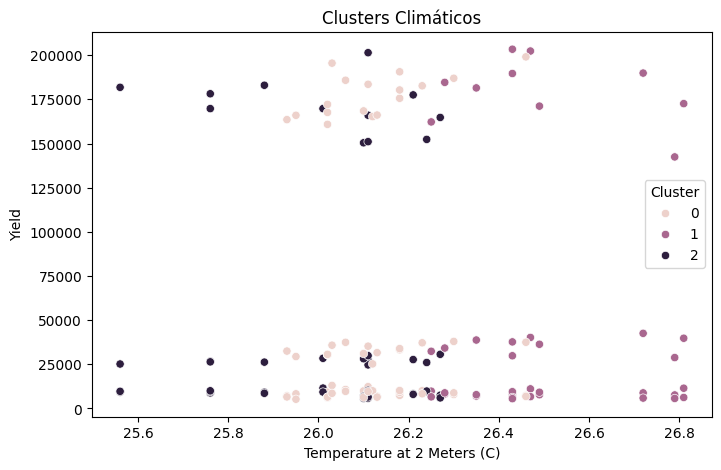

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando apenas variáveis climáticas
X = df[['Precipitation (mm day-1)',
        'Specific Humidity at 2 Meters (g/kg)',
        'Relative Humidity at 2 Meters (%)',
        'Temperature at 2 Meters (C)']]

# Padronizando dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Criando modelo KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualização
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Temperature at 2 Meters (C)'],
    y=df['Yield'],
    hue=df['Cluster']
)
plt.title("Clusters Climáticos")
plt.show()

### Clusters Climáticos

O gráfico de dispersão mostra a relação entre **Temperatura a 2m (°C)** e **Yield**, segmentada em três clusters distintos.  
- Apesar da temperatura variar pouco (entre ~25,6 °C e ~26,8 °C), os clusters revelam **padrões diferentes de rendimento agrícola**.  
- Cada grupo apresenta comportamento próprio do Yield, sugerindo que fatores adicionais (como tipo de cultura, características do solo ou práticas agrícolas) podem estar influenciando os resultados.  
- A clusterização foi capaz de identificar **estruturas ocultas nos dados** que não aparecem em análises lineares simples.  

**Conclusão:**  
A análise de clusters evidencia que o rendimento agrícola não depende apenas da temperatura de forma linear. A segmentação dos dados ajuda a compreender melhor os diferentes cenários produtivos e pode ser utilizada para aprimorar os modelos preditivos.

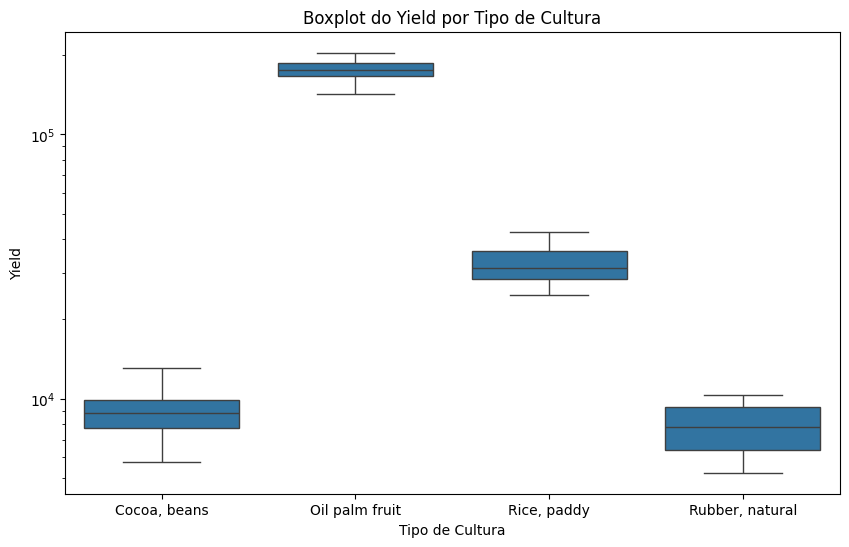

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Crop'], y=df['Yield'])
plt.yscale('log')  # opcional, para lidar com valores muito altos
plt.title("Boxplot do Yield por Tipo de Cultura")
plt.xlabel("Tipo de Cultura")
plt.ylabel("Yield")
plt.show()

### Boxplot do Yield por Tipo de Cultura

O boxplot compara a distribuição do **Yield** entre diferentes tipos de cultura, utilizando escala logarítmica para melhor visualização:  
- **Oil palm fruit** apresenta os maiores valores de rendimento, com mediana elevada e ampla dispersão.  
- **Rice, paddy** vem em seguida, também com valores relativamente altos.  
- **Cocoa, beans** e **Rubber, natural** possuem rendimentos mais baixos, com distribuições concentradas em faixas menores.  
- A presença de outliers em todas as culturas indica variabilidade significativa dentro de cada grupo.  

**Conclusão:**  
O tipo de cultura exerce forte influência sobre o rendimento agrícola. A escala logarítmica evidencia diferenças de ordem de magnitude entre as culturas, mostrando que algumas são naturalmente mais produtivas. Essa informação é essencial para a modelagem, pois sugere que o **tipo de cultura** deve ser considerado como variável explicativa importante

In [22]:
import numpy as np

# Quartis
Q1 = df['Yield'].quantile(0.25)
Q3 = df['Yield'].quantile(0.75)
IQR = Q3 - Q1

# Limites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Selecionando registros outliers
outliers = df[(df['Yield'] < limite_inferior) | (df['Yield'] > limite_superior)]

print("Outliers identificados:")
print(outliers[['Crop', 'Yield']])

Outliers identificados:
              Crop   Yield
39  Oil palm fruit  169783
40  Oil palm fruit  201436
42  Oil palm fruit  181826
43  Oil palm fruit  178183
44  Oil palm fruit  169781
45  Oil palm fruit  166042
46  Oil palm fruit  165262
47  Oil palm fruit  183004
48  Oil palm fruit  177543
51  Oil palm fruit  172165
52  Oil palm fruit  160862
53  Oil palm fruit  166136
54  Oil palm fruit  163541
55  Oil palm fruit  164772
57  Oil palm fruit  165993
58  Oil palm fruit  167621
59  Oil palm fruit  168476
60  Oil palm fruit  162240
61  Oil palm fruit  175629
62  Oil palm fruit  180323
63  Oil palm fruit  184629
64  Oil palm fruit  190626
65  Oil palm fruit  183544
66  Oil palm fruit  195523
67  Oil palm fruit  182696
68  Oil palm fruit  171189
69  Oil palm fruit  185831
70  Oil palm fruit  186959
71  Oil palm fruit  181496
72  Oil palm fruit  203399
73  Oil palm fruit  202379
74  Oil palm fruit  172601
75  Oil palm fruit  199074
76  Oil palm fruit  189657
77  Oil palm fruit  189896


### Outliers no Yield da Cultura Oil Palm Fruit

Foram identificados diversos valores de **Yield** para *Oil palm fruit* que se destacam como **outliers**:  
- Os rendimentos variam entre ~160 mil e ~203 mil, muito acima da faixa típica observada para outras culturas.  
- A repetição de valores elevados sugere que essa cultura possui uma distribuição naturalmente mais ampla, mas ainda assim esses pontos se afastam da tendência geral.  
- A presença de tantos outliers indica que o **Yield de Oil palm fruit** é altamente variável e pode distorcer análises estatísticas se não for tratado adequadamente.  

**Conclusão:**  
Esses outliers reforçam a necessidade de aplicar técnicas de tratamento, como normalização, transformação logarítmica ou até mesmo modelos robustos, para evitar que valores extremos comprometam a qualidade das previsões. Além disso, é importante considerar que a cultura *Oil palm fruit* pode ter características produtivas intrinsecamente diferentes das demais.

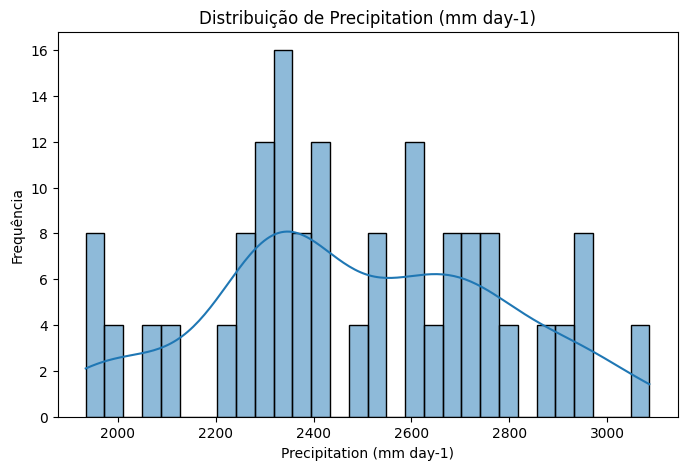

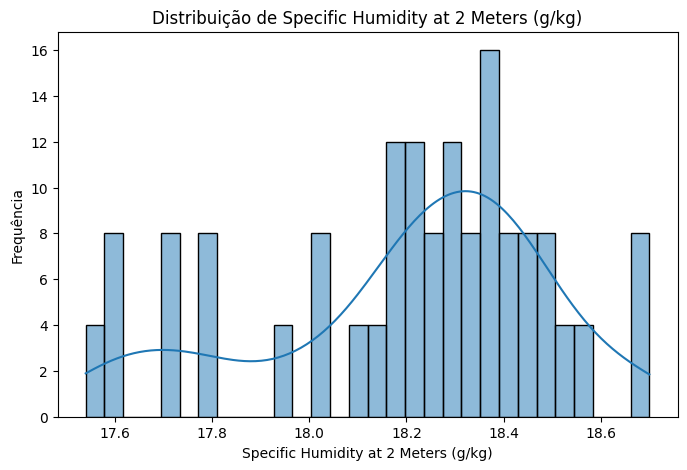

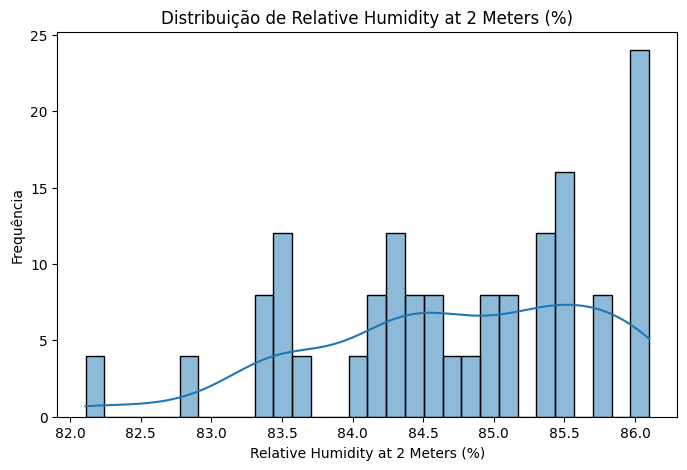

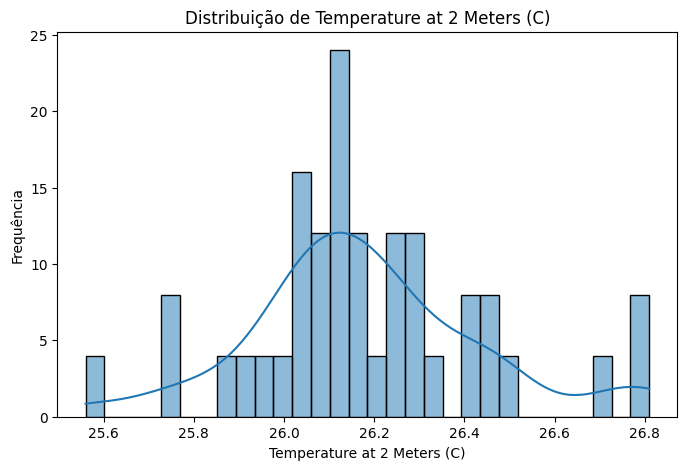

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

climatic_vars = [
    'Precipitation (mm day-1)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)'
]

for var in climatic_vars:
    plt.figure(figsize=(8,5))
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f"Distribuição de {var}")
    plt.xlabel(var)
    plt.ylabel("Frequência")
    plt.show()

### Distribuição das Variáveis Climáticas

Os histogramas com curva KDE mostram a distribuição das principais variáveis climáticas do dataset:

- **Precipitação (mm/day):**  
  Distribuição relativamente simétrica, concentrada entre ~1950 e ~3100 mm/dia. Não há evidência clara de outliers, indicando estabilidade.

- **Umidade específica a 2m (g/kg):**  
  Valores concentrados em faixa muito estreita (~17,6 a ~18,6 g/kg), com pico próximo de 18,4 g/kg. Variável altamente estável.

- **Umidade relativa a 2m (%):**  
  Distribuição homogênea entre ~82% e ~86%, com maior frequência em torno de 86%. Pouca dispersão, confirmando consistência.

- **Temperatura a 2m (°C):**  
  Valores concentrados entre ~25,6 °C e ~26,8 °C, com pico em torno de 26,2 °C. Distribuição próxima da normal, mas com baixa variabilidade.

**Conclusão:**  
As variáveis climáticas apresentam distribuições homogêneas e pouca variabilidade. Essa estabilidade sugere que, isoladamente, elas podem ter baixo poder explicativo sobre o **Yield**. No entanto, sua análise conjunta e em interação com variáveis de solo e tipo de cultura pode revelar padrões mais relevantes para a modelagem preditiva.

# Análise Exploratória Completa

## 1. Matriz de Correlação
- As variáveis climáticas apresentam correlações entre si, mas o **Yield** não mostra relação linear significativa com nenhuma delas.  
- Destaque: Temperatura correlaciona moderadamente com umidade específica (0.70), mas o Yield permanece praticamente independente.

**Conclusão:**  
O rendimento agrícola não pode ser explicado por relações lineares simples com variáveis climáticas.

---

## 2. Regressão Linear
- Modelo treinado com variáveis climáticas → **R² = -0.073** e **MSE elevado**.  
- Resultado negativo indica que o modelo performou pior que a média simples.

**Conclusão:**  
A regressão linear não é adequada para prever o Yield. É necessário explorar modelos não lineares ou mais robustos.

---

## 3. Clusters Climáticos
- Segmentação revelou **três grupos distintos** de comportamento do Yield em relação à temperatura.  
- Mesmo com pouca variação térmica, os clusters mostram padrões diferentes de produtividade.

**Conclusão:**  
A clusterização evidencia heterogeneidade nos dados, sugerindo que segmentar os cenários climáticos pode melhorar a modelagem.

---

## 4. Boxplot por Tipo de Cultura
- **Oil palm fruit** apresenta os maiores rendimentos, seguido por **Rice, paddy**.  
- **Cocoa, beans** e **Rubber, natural** têm distribuições mais baixas.  
- Escala logarítmica mostra diferenças de ordem de magnitude entre culturas.

**Conclusão:**  
O tipo de cultura é um fator determinante no Yield e deve ser incluído como variável explicativa.

---

## 5. Outliers
- Diversos valores extremos identificados em **Oil palm fruit**, variando entre ~160 mil e ~203 mil.  
- Essa alta variabilidade pode distorcer análises estatísticas.

**Conclusão:**  
É necessário aplicar técnicas de tratamento (normalização, modelos robustos) para lidar com outliers.

---

## 6. Distribuição das Variáveis Climáticas
- **Precipitação:** distribuição simétrica, sem grandes extremos.  
- **Umidade específica:** faixa estreita, altamente estável.  
- **Umidade relativa:** valores concentrados em torno de 86%, pouca dispersão.  
- **Temperatura:** distribuição próxima da normal, mas com baixa variabilidade.

**Conclusão:**  
As variáveis climáticas são homogêneas e pouco variáveis. Isoladamente, têm baixo poder explicativo sobre o Yield, mas podem ser relevantes em interação com outras variáveis.

---

# Síntese Final
A análise exploratória mostra que:
- O **Yield** não depende linearmente das variáveis climáticas.  
- O **tipo de cultura** e a **segmentação por clusters** revelam padrões mais fortes.  
- Outliers e baixa variabilidade climática exigem técnicas robustas de modelagem.  

**Próximo passo:**  
Testar modelos não lineares (árvores de decisão, random forest, gradient boosting) e incluir variáveis categóricas (tipo de cultura) para capturar melhor a complexidade do rendimento agrícola.